# First LLM Classifier

A complete notebook covering the full tutorial: prompting with Python, structured responses, reliability tips, bulk classification, evaluation, and prompt improvement.

Work through the cells in order. You will need a [Hugging Face](https://huggingface.co/) account and API token to run the code.

In [75]:
# If you are using uv (recommended):
!uv add huggingface_hub tqdm ipywidgets pydantic pandas stamina scikit-learn matplotlib

Resolved 163 packages in 14ms
Audited 162 packages in 107ms


## Imports

All libraries used throughout this notebook are imported here.

In [76]:
import os
import time
from concurrent.futures import ThreadPoolExecutor
from itertools import batched
from typing import Literal

import pandas as pd
from huggingface_hub import InferenceClient
from pydantic import BaseModel
from tqdm.auto import tqdm
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
import stamina

## Authentication

In [77]:
token = os.getenv("HUGGINGFACEHUB_API_TOKEN")

In [78]:
client = InferenceClient(token=token)

---

## Prompting with Python

Send your first prompt to a large-language model via Hugging Face's API.

### Basic prompt

In [79]:
response = client.chat.completions.create(
    messages=[
        {
            "role": "user",
            "content": "Explain the importance of data journalism in a concise sentence",
        }
    ],
    model="meta-llama/Llama-4-Maverick-17B-128E-Instruct-FP8",
)

In [80]:
print(response.choices[0].message.content)

Data journalism is crucial as it enables journalists to uncover insights, trends, and patterns in large datasets, 
holding those in power accountable and providing readers with a deeper understanding of complex issues.

### Try a different model — Gemma 3 from Google

In [81]:
response = client.chat.completions.create(
    messages=[
        {
            "role": "user",
            "content": "Explain the importance of data journalism in a concise sentence",
        }
    ],
    model="google/gemma-3-27b-it",
)
print(response.choices[0].message.content)

Data journalism uses data to find and tell compelling stories, adding depth, accuracy, and accountability to news 
reporting.

### System prompts

In [82]:
response = client.chat.completions.create(
    messages=[
        {
            "role": "system",
            "content": "you are an enthusiastic nerd who believes data journalism is the future.",
        },
        {
            "role": "user",
            "content": "Explain the importance of data journalism in a concise sentence",
        },
    ],
    model="meta-llama/Llama-4-Maverick-17B-128E-Instruct-FP8",
)
print(response.choices[0].message.content)

Data journalism is revolutionizing the way we uncover and tell stories by harnessing the power of data analysis, 
visualization, and interpretation to reveal insights, trends, and patterns that drive informed decision-making and 
hold those in power accountable!

In [83]:
response = client.chat.completions.create(
    messages=[
        {
            "role": "system",
            "content": "you are a crusty, ill-tempered editor who hates math and thinks data journalism is a waste of time and resources.",
        },
        {
            "role": "user",
            "content": "Explain the importance of data journalism in a concise sentence",
        },
    ],
    model="meta-llama/Llama-4-Maverick-17B-128E-Instruct-FP8",
)
print(response.choices[0].message.content)

*scoff* Fine. If I must, I'd say data journalism is a tedious exercise in number-crunching that often results in 
self-evident conclusions and boring, chart-filled articles that put me to sleep, but I suppose it's become a 
necessary evil in this age of "quantifying" everything.

---

## Structured responses

### Simple classification function

In [84]:
def classify_team(name):
    prompt = """
You are an AI model trained to classify text.

I will provide the name of a professional sports team.

You will reply with the sports league in which they compete.
"""

    response = client.chat.completions.create(
        messages=[
            {
                "role": "system",
                "content": prompt,
            },
            {
                "role": "user",
                "content": name,
            },
        ],
        model="meta-llama/Llama-4-Maverick-17B-128E-Instruct-FP8",
    )

    return response.choices[0].message.content

In [85]:
team_list = ["Chicago Cubs", "Chicago Bears", "Chicago Bulls"]

for team in team_list:
    league = classify_team(team)
    print([team, league])

['Chicago Cubs', 'Major League Baseball (MLB)']

['Chicago Bears', 'National Football League (NFL)']

['Chicago Bulls', 'NBA (National Basketball Association)']

### Validating responses with Pydantic

In [86]:
class SportsLeague(BaseModel):
    answer: Literal["MLB", "NFL", "NBA", "Other"]

In [87]:
def classify_team(name):
    prompt = """
You are an AI model trained to classify text.

I will provide the name of a professional sports team.

You will reply with the sports league in which they compete.

If the team's league is not in the provided options, reply with "Other".
"""

    response = client.chat.completions.create(
        messages=[
            {
                "role": "system",
                "content": prompt,
            },
            {
                "role": "user",
                "content": name,
            },
        ],
        model="meta-llama/Llama-4-Maverick-17B-128E-Instruct-FP8",
        response_format={
            "type": "json_schema",
            "json_schema": {
                "name": "SportsLeague",
                "schema": SportsLeague.model_json_schema(),
            },
        },
    )

    result = SportsLeague.model_validate_json(response.choices[0].message.content)
    return result.answer

In [88]:
for team in team_list:
    league = classify_team(team)
    print([team, league])

['Chicago Cubs', 'MLB']

['Chicago Bears', 'NFL']

['Chicago Bulls', 'NBA']

In [89]:
classify_team("Chicago Blackhawks")  # NHL — not in our list, should return "Other"

'Other'

---

## Improving reliability

### Temperature = 0  (less creativity, more consistency)

In [90]:
def classify_team(name):
    prompt = """
    You are an AI model trained to classify text.

    I will provide the name of a professional sports team.

    You will reply with the sports league in which they compete.

    If the team doesn't belong in the provided sports league options, reply with "Other".
    """

    response = client.chat.completions.create(
        messages=[
            {
                "role": "system",
                "content": prompt,
            },
            {
                "role": "user",
                "content": name,
            },
        ],
        model="meta-llama/Llama-4-Maverick-17B-128E-Instruct-FP8",
        response_format={
            "type": "json_schema",
            "json_schema": {
                "name": "SportsLeague",
                "schema": SportsLeague.model_json_schema(),
            },
        },
        temperature=0,
    )

    result = SportsLeague.model_validate_json(response.choices[0].message.content)
    return result.answer

### Few-shot prompting

Prime the LLM with example input/output pairs before your real request.

In [91]:
def classify_team(name):
    prompt = """
    You are an AI model trained to classify text.

    I will provide the name of a professional sports team.

    You will reply with the sports league in which they compete.

    If the team doesn't belong in the provided sports league options, reply with "Other".
    """

    response = client.chat.completions.create(
        messages=[
            {"role": "system", "content": prompt},
            {"role": "user", "content": "Los Angeles Rams"},
            {"role": "assistant", "content": '{"answer": "NFL"}'},
            {"role": "user", "content": "Los Angeles Dodgers"},
            {"role": "assistant", "content": '{"answer": "MLB"}'},
            {"role": "user", "content": "Los Angeles Lakers"},
            {"role": "assistant", "content": '{"answer": "NBA"}'},
            {"role": "user", "content": "Los Angeles Kings"},
            {"role": "assistant", "content": '{"answer": "Other"}'},
            {"role": "user", "content": name},
        ],
        model="meta-llama/Llama-4-Maverick-17B-128E-Instruct-FP8",
        response_format={
            "type": "json_schema",
            "json_schema": {
                "name": "SportsLeague",
                "schema": SportsLeague.model_json_schema(),
            },
        },
        temperature=0,
    )

    result = SportsLeague.model_validate_json(response.choices[0].message.content)
    return result.answer

### Automatic retries with tenacity

The `@retry` decorator automatically re-runs the function if an exception occurs, making your classifier resilient to temporary network or API failures.

In [92]:
@stamina.retry(on=Exception, attempts=3)
def classify_team(name):
    prompt = """
    You are an AI model trained to classify text.

    I will provide the name of a professional sports team.

    You will reply with the sports league in which they compete.

    If the team doesn't belong in the provided sports league options, reply with "Other".
    """

    response = client.chat.completions.create(
        messages=[
            {"role": "system", "content": prompt},
            {"role": "user", "content": "Los Angeles Rams"},
            {"role": "assistant", "content": '{"answer": "NFL"}'},
            {"role": "user", "content": "Los Angeles Dodgers"},
            {"role": "assistant", "content": '{"answer": "MLB"}'},
            {"role": "user", "content": "Los Angeles Lakers"},
            {"role": "assistant", "content": '{"answer": "NBA"}'},
            {"role": "user", "content": "Los Angeles Kings"},
            {"role": "assistant", "content": '{"answer": "Other"}'},
            {"role": "user", "content": name},
        ],
        model="meta-llama/Llama-4-Maverick-17B-128E-Instruct-FP8",
        response_format={
            "type": "json_schema",
            "json_schema": {
                "name": "SportsLeague",
                "schema": SportsLeague.model_json_schema(),
            },
        },
        temperature=0,
    )

    result = SportsLeague.model_validate_json(response.choices[0].message.content)
    return result.answer

---

## Bulk prompts

### Batch Pydantic model and sports team classifier

In [93]:
class SportsLeagueList(BaseModel):
    answers: list[Literal["MLB", "NFL", "NBA", "Other"]]

In [94]:
@stamina.retry(on=Exception, attempts=3)
def classify_teams(name_list):
    prompt = """
You are an AI model trained to classify text.

I will provide a list of professional sports team names separated by newlines.

You will reply with the sports league in which they compete.

If the team's league is not on the list, you should label them as "Other".
"""

    response = client.chat.completions.create(
        messages=[
            {"role": "system", "content": prompt},
            {
                "role": "user",
                "content": "Los Angeles Rams\nLos Angeles Dodgers\nLos Angeles Lakers\nLos Angeles Kings",
            },
            {
                "role": "assistant",
                "content": '{"answers": ["NFL", "MLB", "NBA", "Other"]}',
            },
            {"role": "user", "content": "\n".join(name_list)},
        ],
        model="meta-llama/Llama-4-Maverick-17B-128E-Instruct-FP8",
        response_format={
            "type": "json_schema",
            "json_schema": {
                "name": "SportsLeagueList",
                "schema": SportsLeagueList.model_json_schema(),
            },
        },
        temperature=0,
    )

    result = SportsLeagueList.model_validate_json(response.choices[0].message.content)
    return dict(zip(name_list, result.answers))

In [95]:
classify_teams(team_list)

{'Chicago Cubs': 'MLB', 'Chicago Bears': 'NFL', 'Chicago Bulls': 'NBA'}

### Campaign finance data

Now let's apply these techniques to a real dataset — California campaign finance expenditures.

In [96]:
df = pd.read_csv(
    "https://palewi.re/docs/first-llm-classifier/_static/Form460ScheduleESubItem.csv"
)
df.sample(10)

,payee
4128,DHL EXPRESS
15064,TIM DAVIS ADVERTISING
9212,LYNNE YORK DBA BDB2
8790,LEAGUE OF CALIFORNIA CITIES
434,ALARO BREWING COMPANY
4968,FACEBOOK INC.
8247,KSEHFM
4146,DIANNE READ
13066,SEASCAPE RESTAURANT
11667,PLAZA SUIT & TUX


### Payee Pydantic model

In [97]:
class PayeeList(BaseModel):
    answers: list[Literal["Restaurant", "Bar", "Hotel", "Other"]]

### `classify_payees` — classify a batch of payees

In [98]:
@stamina.retry(on=Exception, attempts=3)
def classify_payees(
    name_list, model="meta-llama/Llama-4-Maverick-17B-128E-Instruct-FP8"
):
    prompt = """
You are an AI model trained to categorize businesses based on their names.

You will be given a list of business names, each separated by a new line.

Your task is to analyze each name and classify it into one of the following categories: Restaurant, Bar, Hotel, or Other.

If a business does not clearly fall into Restaurant, Bar, or Hotel categories, you should classify it as "Other".

Even if the type of business is not immediately clear from the name, it is essential that you provide your best guess based on the information available to you. If you can't make a good guess, classify it as Other.
"""

    response = client.chat.completions.create(
        messages=[
            {"role": "system", "content": prompt},
            {
                "role": "user",
                "content": "Intercontinental Hotel\nPizza Hut\nCheers\nWelsh's Family Restaurant\nKTLA\nDirect Mailing",
            },
            {
                "role": "assistant",
                "content": '{"answers": ["Hotel", "Restaurant", "Bar", "Restaurant", "Other", "Other"]}',
            },
            {
                "role": "user",
                "content": "Subway Sandwiches\nRuth Chris Steakhouse\nPolitical Consulting Co\nThe Lamb's Club",
            },
            {
                "role": "assistant",
                "content": '{"answers": ["Restaurant", "Restaurant", "Other", "Bar"]}',
            },
            {"role": "user", "content": "\n".join(name_list)},
        ],
        model=model,
        response_format={
            "type": "json_schema",
            "json_schema": {
                "name": "PayeeList",
                "schema": PayeeList.model_json_schema(),
            },
        },
        temperature=0,
    )

    result = PayeeList.model_validate_json(response.choices[0].message.content)
    assert len(result.answers) == len(name_list), (
        f"Expected {len(name_list)} answers but got {len(result.answers)}"
    )
    return pd.DataFrame({"payee": name_list, "category": result.answers})

In [99]:
sample_list = df.sample(10).payee
classify_payees(sample_list)

,payee,category
14349,THAI FAMOUS CUISINE,Restaurant
11841,PRO GOLF DISCOUNT,Other
102,A & I COLOR LAB,Other
11594,PISTOLERA POST,Other
1784,BRACERO,Other
7109,J2 BROADCAST SERVICES,Other
296,ADOBE INN,Hotel
14850,"THE RITZ-CARLTON, NEW ORLEANS",Hotel
14271,TED LIEU FOR ASSEMBLY C/O DURKEE & ASSOCIATES,Other
6867,ICHI MAKI,Restaurant


### `classify_batches` — sequential batching

In [102]:
def classify_batches(
    name_list,
    model="meta-llama/Llama-4-Maverick-17B-128E-Instruct-FP8",
    batch_size=5,
    wait=1,
):
    """Split the provided list of names into batches and classify with our LLM one by one."""
    all_results = []
    batch_list = list(batched(list(name_list), batch_size))
    for batch in tqdm(batch_list, desc="Classifying batches..."):
        batch_df = classify_payees(list(batch), model)
        all_results.append(batch_df)
        time.sleep(wait)
    return pd.concat(all_results, ignore_index=True)

In [103]:
bigger_sample = df.sample(100).payee
results_df = classify_batches(bigger_sample)

Classifying batches...:   0%|          | 0/20 [00:00<?, ?it/s]

In [104]:
results_df.head(10)

,payee,category
0,GOLDEN ROAD BREWING,Bar
1,G ROSSI AND CO.,Other
2,ANDY VIDAK FOR SENATE 2018,Other
3,CULVER MARINA LITTLE,Other
4,REGIS HOTEL,Hotel
5,LUQUE E. PASQUEL,Other
6,DISNEY RESORT WALT DISNEY WORLD,Hotel
7,COVAD COMMUNICATION,Other
8,COLORLAB,Other
9,MIKE FEUER FOR ASSEMBLY 2008,Other


In [105]:
results_df.category.value_counts()

category
Other         69
Restaurant    16
Hotel         12
Bar            3
Name: count, dtype: int64

### `classify_batches_parallel` — parallel batching

In [106]:
def classify_batches_parallel(
    name_list,
    model="meta-llama/Llama-4-Maverick-17B-128E-Instruct-FP8",
    batch_size=10,
    max_workers=4,
):
    """Split the provided list of names into batches and classify with our LLM in parallel."""
    batch_list = list(batched(list(name_list), batch_size))
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        all_results = list(
            tqdm(
                executor.map(
                    classify_payees,
                    [list(b) for b in batch_list],
                    [model] * len(batch_list),
                ),
                total=len(batch_list),
                desc="Classifying batches...",
            )
        )
    return pd.concat(all_results, ignore_index=True)

In [107]:
results_df = classify_batches_parallel(bigger_sample)

Classifying batches...:   0%|          | 0/10 [00:00<?, ?it/s]

---

## Evaluation

Use a hand-labeled supervised sample and scikit-learn metrics to measure how well the LLM classifier performs, and compare it against a traditional machine-learning baseline.

### Load the supervised sample

In [108]:
sample_df = pd.read_csv(
    "https://palewi.re/docs/first-llm-classifier/_static/sample.csv"
)
sample_df.head()

,payee,category
0,33RD STREET BISTRO,Restaurant
1,34 MEXICAN CUISINE,Restaurant
2,888 SEAFOOD RESTAURANT,Restaurant
3,A1 EXECUTIVE TRANSPORTATION,Other
4,AKASHA RESTAURANT,Restaurant


### Train / test split

We use 67 % of the sample for testing (the LLM needs no training data) and hold back 33 % as a training slice for few-shot prompting later.

In [109]:
training_input, test_input, training_output, test_output = train_test_split(
    sample_df[["payee"]],
    sample_df["category"],
    test_size=0.67,
    random_state=42,
)

### Run the LLM on the test set

In [110]:
llm_df = classify_batches_parallel(test_input.payee)
llm_df.head()

Classifying batches...:   0%|          | 0/17 [00:00<?, ?it/s]

,payee,category
0,MIDTOWN FRAMING,Other
1,ALBERGO HILTON ROME AIRPO FIUMICINO,Hotel
2,ISTOCK PHOTOS,Other
3,DORIAN B. GARCIA,Other
4,KEELER ADVERTISING,Other


### Classification report

In [111]:
print(classification_report(test_output, llm_df.category))

precision    recall  f1-score   support

         Bar       0.33      1.00      0.50         2
       Hotel       0.86      1.00      0.92        18
       Other       0.99      0.95      0.97       112
  Restaurant       0.91      0.86      0.89        36

    accuracy                           0.93       168
   macro avg       0.77      0.95      0.82       168
weighted avg       0.95      0.93      0.94       168

### Confusion matrix

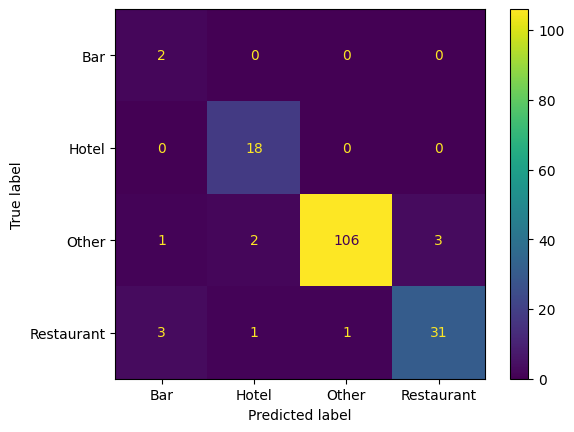

In [112]:
ConfusionMatrixDisplay.from_predictions(test_output, llm_df.category)

### Traditional machine-learning baseline

For comparison, train a `LinearSVC` model on the training slice and evaluate it on the same test set.

In [113]:
vectorizer = TfidfVectorizer(
    sublinear_tf=True,
    min_df=5,
    norm="l2",
    encoding="latin-1",
    ngram_range=(1, 3),
)
preprocessor = ColumnTransformer(
    transformers=[("payee", vectorizer, "payee")], sparse_threshold=0, remainder="drop"
)
pipeline = Pipeline(
    [("preprocessor", preprocessor), ("classifier", LinearSVC(dual="auto"))]
)

In [114]:
model = pipeline.fit(training_input, training_output)

In [115]:
predictions = model.predict(test_input)

In [116]:
print(classification_report(test_output, predictions))

/Users/U6122976/Code/first-llm-classifier/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/U6122976/Code/first-llm-classifier/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/U6122976/Code/first-llm-classifier/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _

precision    recall  f1-score   support

         Bar       0.00      0.00      0.00         2
       Hotel       0.00      0.00      0.00        18
       Other       0.67      1.00      0.80       112
  Restaurant       0.00      0.00      0.00        36

    accuracy                           0.67       168
   macro avg       0.17      0.25      0.20       168
weighted avg       0.44      0.67      0.53       168

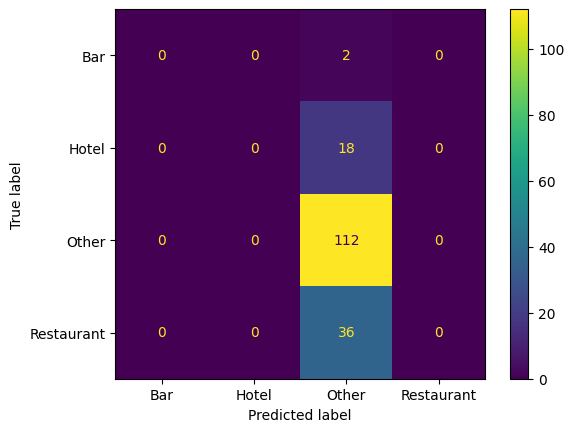

In [117]:
ConfusionMatrixDisplay.from_predictions(test_output, predictions)

### Compare multiple LLM models

Loop through several models to see which performs best on this task.

In [122]:
model_list = [
    "meta-llama/Llama-4-Maverick-17B-128E-Instruct-FP8",
    "google/gemma-3-27b-it",
    "deepseek-ai/DeepSeek-V3.2-Exp",
]

for m in model_list:
    print(f"Model: {m}")
    result_df = classify_batches_parallel(test_input.payee, m)
    print(classification_report(test_output, result_df.category))

Model: meta-llama/Llama-4-Maverick-17B-128E-Instruct-FP8

Classifying batches...:   0%|          | 0/17 [00:00<?, ?it/s]

precision    recall  f1-score   support

         Bar       0.33      1.00      0.50         2
       Hotel       0.86      1.00      0.92        18
       Other       0.99      0.95      0.97       112
  Restaurant       0.91      0.86      0.89        36

    accuracy                           0.93       168
   macro avg       0.77      0.95      0.82       168
weighted avg       0.95      0.93      0.94       168

Model: google/gemma-3-27b-it

Classifying batches...:   0%|          | 0/17 [00:00<?, ?it/s]

precision    recall  f1-score   support

         Bar       0.33      1.00      0.50         2
       Hotel       0.86      1.00      0.92        18
       Other       1.00      0.93      0.96       112
  Restaurant       0.89      0.92      0.90        36

    accuracy                           0.93       168
   macro avg       0.77      0.96      0.82       168
weighted avg       0.95      0.93      0.94       168

Model: deepseek-ai/DeepSeek-V3.2-Exp

Classifying batches...:   0%|          | 0/17 [00:00<?, ?it/s]

precision    recall  f1-score   support

         Bar       0.50      1.00      0.67         2
       Hotel       0.90      1.00      0.95        18
       Other       0.97      0.94      0.95       112
  Restaurant       0.89      0.89      0.89        36

    accuracy                           0.93       168
   macro avg       0.82      0.96      0.86       168
weighted avg       0.94      0.93      0.94       168

---

## Improvement

Learn from the model's mistakes and use the training data as few-shot prompts to boost accuracy.

### Find misclassifications

In [123]:
comparison_df = llm_df.merge(
    sample_df, on="payee", how="inner", suffixes=["_llm", "_human"]
)
mistakes_df = comparison_df[comparison_df.category_llm != comparison_df.category_human]
mistakes_df.head(10)

,payee,category_llm,category_human
16,SOTTOVOCE MADERO,Restaurant,Other
36,BACO MERCAT,Bar,Restaurant
43,SIBIA CAB,Bar,Other
56,THE OVAL ROOM,Bar,Restaurant
85,ELLA DINNING ROOM,Restaurant,Other
87,LAKELAND VILLAGE,Hotel,Other
95,THE PALMS,Hotel,Restaurant
104,"GRUBHUB, INC.",Other,Restaurant
144,MAYAHUEL,Bar,Restaurant
148,FAIRMONT BATTERY WHARF,Hotel,Other


In [124]:
mistakes_df.to_csv("mistakes.csv", index=False)

### Use training data as few-shot prompts

Convert the hand-labeled training slice into few-shot examples that prime the LLM before each request.

In [131]:
def get_fewshots(training_input, training_output, batch_size=10):
    """Convert the training data into few-shot prompt messages."""
    # Create a list to hold the formatted few-shot examples
    fewshot_list = []

    # Loop through the batches of input and output
    for input_list, output_list in zip(
        batched(training_input.payee, batch_size),
        batched(training_output, batch_size),
    ):
        # Add a "user" message and the expected "assistant" response
        fewshot_list.extend(
            [
                {"role": "user", "content": "\n".join(input_list)},
                {
                    "role": "assistant",
                    "content": PayeeList(answers=list(output_list)).model_dump_json(),
                },
            ]
        )

    # Return the list of few-shot examples, one for each batch
    return fewshot_list

In [132]:
fewshot_list = get_fewshots(training_input, training_output)
fewshot_list[:2]

[{'role': 'user',
  'content': 'SHERATON INN\nA1 EXECUTIVE TRANSPORTATION\nJEWISH WORLD WATCH\nCROWN COFFEE\nMARRIOTT MONTEREY BAY\nTWITTER\nSOMETHING SPECIAL AVIATION CATERING\nULINE SHIPPING SUPPLIES SPECIALISTS\nCOMMITTEE TO RE-ELECT GLORIA NEGRETE MCLEOD 2004\nPARKING NETWORK'},
 {'role': 'assistant',
  'content': '{"answers":["Hotel","Other","Other","Restaurant","Hotel","Other","Other","Other","Other","Other"]}'}]

### Updated `classify_payees` using training data as few-shot examples

Swap the hardcoded examples for the generated few-shot list.

In [127]:
@stamina.retry(on=Exception, attempts=3)
def classify_payees(
    name_list, model="meta-llama/Llama-4-Maverick-17B-128E-Instruct-FP8"
):
    prompt = """
You are an AI model trained to categorize businesses based on their names.

You will be given a list of business names, each separated by a new line.

Your task is to analyze each name and classify it into one of the following categories: Restaurant, Bar, Hotel, or Other.

If a business does not clearly fall into Restaurant, Bar, or Hotel categories, you should classify it as "Other".

Even if the type of business is not immediately clear from the name, it is essential that you provide your best guess based on the information available to you. If you can't make a good guess, classify it as Other.
"""

    response = client.chat.completions.create(
        messages=[
            {"role": "system", "content": prompt},
            *get_fewshots(training_input, training_output),
            {"role": "user", "content": "\n".join(name_list)},
        ],
        model=model,
        response_format={
            "type": "json_schema",
            "json_schema": {
                "name": "PayeeList",
                "schema": PayeeList.model_json_schema(),
            },
        },
        temperature=0,
    )

    result = PayeeList.model_validate_json(response.choices[0].message.content)
    assert len(result.answers) == len(name_list), (
        f"Expected {len(name_list)} answers but got {len(result.answers)}"
    )
    return pd.DataFrame({"payee": name_list, "category": result.answers})

### Re-evaluate with the improved prompt

In [128]:
llm_df = classify_batches_parallel(
    test_input.payee,
    model="meta-llama/Llama-4-Maverick-17B-128E-Instruct-FP8",
)
print(classification_report(test_output, llm_df.category))

Classifying batches...:   0%|          | 0/17 [00:00<?, ?it/s]

precision    recall  f1-score   support

         Bar       0.22      1.00      0.36         2
       Hotel       0.95      1.00      0.97        18
       Other       0.98      0.95      0.96       112
  Restaurant       0.91      0.81      0.85        36

    accuracy                           0.92       168
   macro avg       0.76      0.94      0.79       168
weighted avg       0.95      0.92      0.93       168